In [1]:
import sys
import torch
import functools
import matplotlib.pyplot as plt
import argparse, yaml, os
import torch.optim.lr_scheduler as lr_scheduler
import torchvision.transforms as transforms
import seaborn as sns
import pandas as pd
import tqdm
import glob

from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from types import SimpleNamespace

from IPython.display import clear_output

sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params as model_params_tm
from texture_prior.params import statistics_set, texture_dataset
from texture_prior.utils import path

sys.path.append('../utls/')
sys.path.append('../src/model/')
sys.path.append("/om2/user/bjmedina/auditory-memory/memory/")
import DistanceMemoryModel
import encoders

from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used, load_results_with_exclusion
from utls.dprime import recompute_dprime_by_isi_per_subject
from utls.reliability import compute_itemwise_split_half_reliability
from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir


sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/*wav")
device = 'cuda'
# get soem textures
pc_dims = 256

pc_texture_model = encoders.AudioTextureEncoderPCA(
    statistics_dict=statistics_set.statistics,
    pc_dims=pc_dims,
    model_params=model_params_tm,
    sr=20000,
    rms_level=0.05,
    duration=2.0,
    device=device
)

def compute_likelihood(score_model, input_stats, ckpt):
    """Computing the actual "prior" value
    If the score function can be treated as the vector field govering the temporal evolution
    of $x_t$ then we can integrate the ODE and apply a change of basis to evaluate the prior
    """
    score_model.load_state_dict(torch.load(ckpt))
    input_stats = input_stats.to(device)

    _, bpd = ode_likelihood(input_stats, score_model, marginal_prob_std_fn,
                            diffusion_coeff_fn,
                            input_stats.shape[0], device=device, eps=1e-5)
    
    return bpd

def parse(d):
  x = SimpleNamespace()
  _ = [setattr(x, k, parse(v)) if isinstance(v, dict) else setattr(x, k, v) for k, v in d.items() ]    
  return x

In [2]:
def get_dataset(batch_size, num_workers, 
                stationarity_screen_list='/om2/user/jmhicks/projects/TextureStreaming/stimuli/OVERLAPPED_0.5s_all_4s_sound_list_with_stationarity_score_no_speech_no_music_audioset_matlab_coch_rms0p02.csv', 
                audioset_path='/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/', 
                duration=4):
    dataset = texture_dataset.AudioSetTextures(stationarity_screen_list, audioset_path, duration)
    #return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return dataset

dataloader = get_dataset(16, 4)
audioset_path='/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/'

In [3]:
dataloader.texture_list
unique_sounds = list(set(dataloader.texture_list.filepath.tolist()))
unique_sounds = [f"{audioset_path}{u}" for u in unique_sounds] ## TODO: CREATE NEW SOUNDS WAV FILES THAT ARE CROPPED 
## 2S SOUNDS THAT START AT THE ONSET SEPCIFIED
## THEY SHOULD BE TEMPORARY

,filepath,short_filepath,labels,stationarity_score,within_sound_ranking,onset_time
12,unbalanced_train_segments_downloads_6/YT_AWFMv...,YT_AWFMvRrhj_E.wav,"/m/07yv9,/t/dd00129",-0.610065,1,4.0
36,unbalanced_train_segments_downloads_19/YT_hwb6...,YT_hwb6xI5FiXI.wav,"/m/07yv9,/t/dd00067",-0.686616,1,2.0
37,unbalanced_train_segments_downloads_19/YT_hwb6...,YT_hwb6xI5FiXI.wav,"/m/07yv9,/t/dd00067",-0.682259,2,0.5
38,unbalanced_train_segments_downloads_19/YT_hwb6...,YT_hwb6xI5FiXI.wav,"/m/07yv9,/t/dd00067",-0.682067,3,1.0
39,unbalanced_train_segments_downloads_19/YT_hwb6...,YT_hwb6xI5FiXI.wav,"/m/07yv9,/t/dd00067",-0.679015,4,1.5
...,...,...,...,...,...,...
2670679,unbalanced_train_segments_downloads_92/YT_GGgF...,YT_GGgF3hKbGQo.wav,/m/07rjwbb,-0.633156,8,3.5
2670680,unbalanced_train_segments_downloads_92/YT_GGgF...,YT_GGgF3hKbGQo.wav,/m/07rjwbb,-0.628557,9,4.0
2670681,unbalanced_train_segments_downloads_92/YT_GGgF...,YT_GGgF3hKbGQo.wav,/m/07rjwbb,-0.619838,10,0.5
2670682,unbalanced_train_segments_downloads_92/YT_GGgF...,YT_GGgF3hKbGQo.wav,/m/07rjwbb,-0.616764,11,4.5


In [3]:
unique_sounds = list(set(dataloader.texture_list.filepath.tolist()))
unique_sounds = [f"{audioset_path}{u}" for u in unique_sounds]
print(*unique_sounds[:10], sep='\n')
#texture_indices

/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_91/YT_G_Sm4SDL5Y0.wav
/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_21/YT_onc48YEPyGc.wav
/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_1/YT_1BQ8qH4D4ig.wav
/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_17/YT_bjNNG40qILc.wav
/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_91/YT__gBlDbll794.wav
/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_3/YT_3TqkaDJKKao.wav
/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_13/YT_ROHf-83hnGc.wav
/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_13/YT_QpTlukPbHnY.wav
/om/data/p

In [4]:
# parser.add_argument('--config', type=str, required=True, help='model + data configuration')
# parser.add_argument('--train', action='store_true', help='train the score-based model')
# parser.add_argument('--sample', action='store_true', help='sample from a trained model')
# parser.add_argument('--likelihood_eval', action='store_true', help='evaluate the data likelihood')
# parser.add_argument('--restart', action='store_true')
# parser.add_argument('--mode', type=str, default='textures', choices=['textures', 'mixtures'])

# sys.path.append('/om2/user/lakshmin/audio-prior/')
# from models import ScoreNetAudio, ScoreNetTexture1D, ScoreNetAudioV2
# from utils import synthesis, projection, audio
# from utils.sde_utils import *

import sys
import importlib.util
import os

# Add the new path
audio_prior_path = '/om2/user/lakshmin/audio-prior/'
sys.path.insert(0, audio_prior_path)  # insert at front of sys.path

from models import ScoreNetAudio, ScoreNetTexture1D, ScoreNetAudioV2
from utils import synthesis, projection, audio
from utils.sde_utils import *

config = "/om2/user/bjmedina/auditory-memory/memory/assets/bryan.yaml"
train = False
sample = False
likelihood_eval = True
restart = False
mode = 'textures'

device = 'cuda'

In [5]:
df = yaml.safe_load(open(config))
cfg = parse(df)

print(cfg)

pt_file = torch.load('/om2/user/lakshmin/audio-prior/assets/texture_statistics_4096texturePCs.pt')

namespace(train=namespace(n_epochs=512, batch_size=4096, lr=0.0001), data=namespace(data_root='/om2/user/lakshmin/audio-prior/assets/texture_statistics_4096texturePCs.pt', data_mix_root='/om2/user/lakshmin/audio-prior/assets/mixture_statistics_4096PCs.pt', n_pcs=256, var_scale=False), model=namespace(ckpt_path='ckpts/texture_diffusion2D_prior_{}pcs_mode_{}.pth', use_single_dim_conv=False, embed_dim=256, channels=[32, 64, 128], kernel_size=5, dilations=[1, 2, 4, 8, 16]), sample=namespace(sample_batch_size=4096, num_steps=2500))


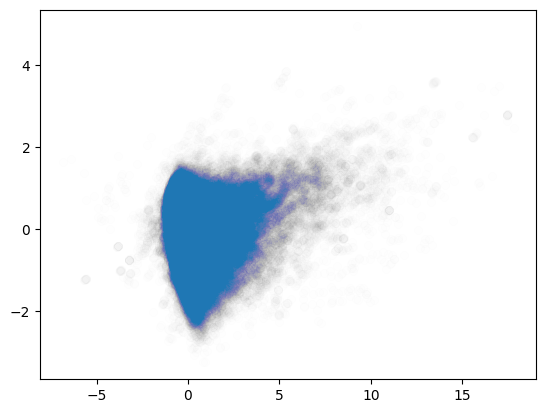

In [26]:
pt_file.shape
plt.scatter(pt_file[:,0], pt_file[:,1], alpha=0.005)

In [6]:
score_model = torch.nn.DataParallel(
                    ScoreNetAudioV2(
                        marginal_prob_std=marginal_prob_std_fn, 
                        channels=cfg.model.channels, 
                        embed_dim=cfg.model.embed_dim
                        )
                    )

score_model = score_model.to(device)

ckpt_path = cfg.model.ckpt_path.format(cfg.data.n_pcs, mode)
ckpt_path = "/om2/user/lakshmin/audio-prior/" + ckpt_path
if 'SLURM_RESTART_COUNT' in os.environ.keys() or restart:
    score_model.load_state_dict(torch.load(ckpt_path))

print(ckpt_path)

/om2/user/lakshmin/audio-prior/ckpts/texture_diffusion2D_prior_256pcs_mode_textures.pth


In [7]:
# from dataloader import TextureStatsDataset
# texture_dataset = TextureStatsDataset(
#                 config=cfg,                        
#                 device=device
#             )
# x = texture_dataset.get_random_batch(1024)


sounds_to_test = 2000
effective_num_sounds = sounds_to_test

rep = []

t_something = 0.01

exp_sounds = unique_sounds

for sound in exp_sounds[:1000]:
    vec = pc_texture_model(sound)

    try:
        if not torch.is_tensor(vec):
            vec = torch.tensor(vec)  # convert if it's a numpy array
        rep.append(vec)

        t = torch.tensor([t_something], device=vec.device).float()

        

        score = score_model(vec.view(1, 1, 1, 256), t)

        # 2. Flatten for norm computation per sample
        score_flat = score.view(score.size(0), -1)  # [B, 256]
        
        # 3. Normalize: divide by norm per sample
        norms = score_flat.norm(p=2, dim=1, keepdim=True) + 1e-8  # prevent division by zero
        unit_score_flat = score_flat / norms  # [B, 256]

        #print(unit_score_flat)
        
        # 4. Reshape back to original format
        unit_score = unit_score_flat.view_as(score)  # [B, 1, 1, 256]

        #input()
        #clear_output(wait=True)

    
    except Exception as e:
        print(e)
        effective_num_sounds -= 1


# Now stack all into one tensor
x = torch.stack(rep).float()  # shape: [N, ...]
x = x.view(len(rep), 1, 1, 256)

bpd_textures = compute_likelihood(score_model, input_stats=x, ckpt=ckpt_path)

x_numpy = x.squeeze(1).squeeze(1).detach().cpu().numpy()


In [8]:
x_orig = x_numpy
idx = np.random.random_integers(0, x_orig.shape[0]-1, cfg.sample.sample_batch_size)
x_orig = x_orig[idx]

/tmp/ipykernel_516893/2645570267.py:2: DeprecationWarning: This function is deprecated. Please call randint(0, 999 + 1) instead
  idx = np.random.random_integers(0, x_orig.shape[0]-1, cfg.sample.sample_batch_size)


In [9]:
sample_batch_size = cfg.sample.sample_batch_size
sampler = Euler_Maruyama_sampler_1d if cfg.model.use_single_dim_conv else Euler_Maruyama_sampler
init_dims = [1, cfg.data.n_pcs] if cfg.model.use_single_dim_conv else [1, 1, cfg.data.n_pcs]

# generate samples using the specified sampler.
samples, trajectory = sampler(
                        score_model,
                        marginal_prob_std_fn,
                        diffusion_coeff_fn,
                        num_steps=cfg.sample.num_steps,
                        batch_size=sample_batch_size,
                        device=device,
                        init_dims=init_dims)

samples = samples.squeeze().detach().cpu().numpy()

100%|██████████| 2500/2500 [01:22<00:00, 30.44it/s]


In [ ]:
plt.scatter(samples[:,1], samples[:,0], alpha=0.4)

In [ ]:
len(trajectory)

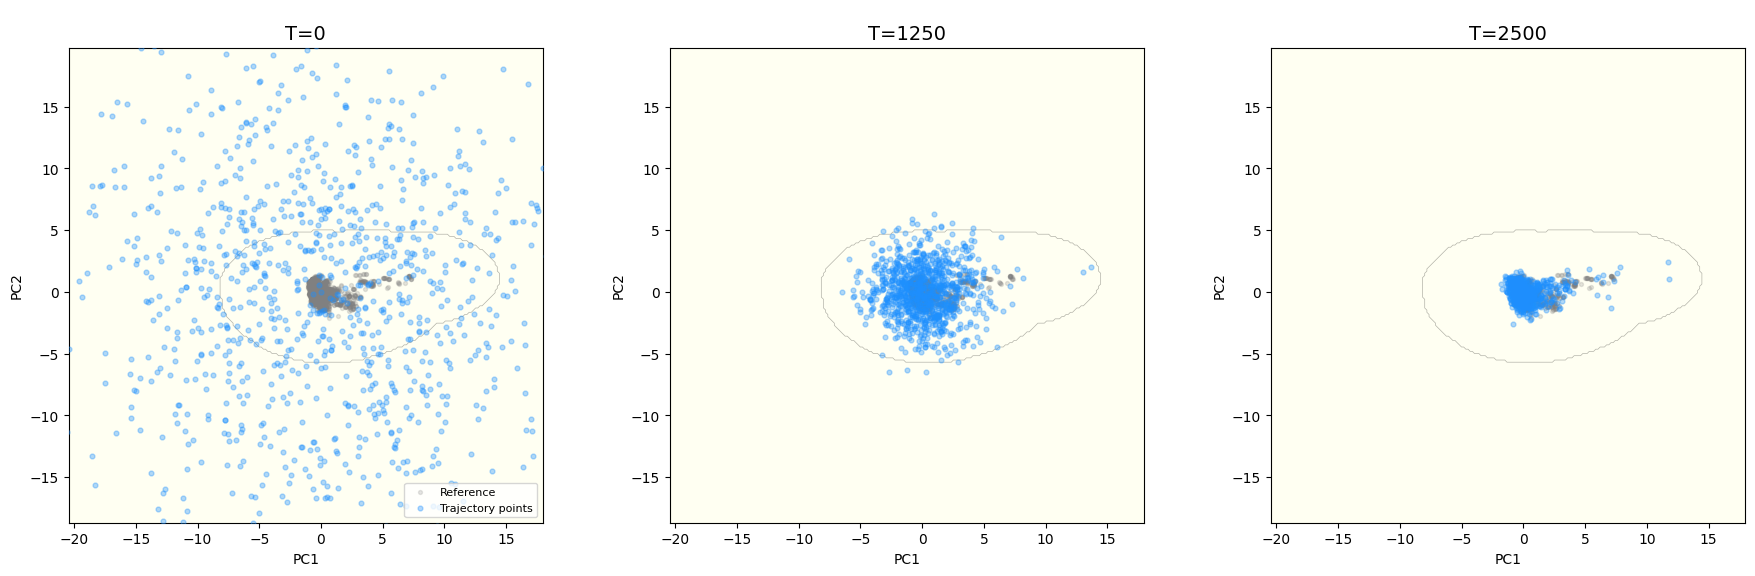

T=2501, N=4096, D=256, showing 1000 trajectories at t=[0, 1250, 2500]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# traj_np already has shape (T, N, D) = (2501, 4096, 256)
# If rebuilding:
traj_np = np.stack([
    (tr.detach().cpu().numpy() if hasattr(tr, "detach") else np.asarray(tr)).squeeze(1).squeeze(1)
    for tr in trajectory
])  # (T, N, D)

traj_np.shape

T, N, D = traj_np.shape
traj_2d = traj_np[:, :, :2]   # (T, N, 2)
Z_train = pt_file[:2000, :2]

# pick timesteps from T axis
t_check = [0, T // 2, T - 1]

# subset trajectories from N axis
rng = np.random.default_rng(
)
n_show = min(1000, N)
n_idx = rng.choice(N, size=n_show, replace=False)

# bounds from train + shown trajectory points at selected timesteps
sel_pts = traj_2d[t_check][:, n_idx, :].reshape(-1, 2)
all_pts = np.vstack([Z_train, sel_pts])
x_min, x_max = np.percentile(all_pts[:, 0], [0.5, 99.5])
y_min, y_max = np.percentile(all_pts[:, 1], [0.5, 99.5])

# KDE background on train data
G0, G1 = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
Q = gaussian_kde(Z_train.T, bw_method=0.15)(np.vstack([G0.ravel(), G1.ravel()])).reshape(G0.shape)

fig, axes = plt.subplots(1, len(t_check), figsize=(18, 5.5), constrained_layout=True)
extent = [x_min, x_max, y_min, y_max]

for ax, t in zip(axes, t_check):
    ax.imshow(Q, origin="lower", cmap="YlOrRd", alpha=0.25, extent=extent, aspect="equal")
    ax.contour(G0, G1, Q, levels=8, colors="k", linewidths=0.5, alpha=0.3)

    ax.scatter(Z_train[:, 0], Z_train[:, 1], c="gray", s=8, alpha=0.2, label="Reference", zorder=2)
    ax.scatter(traj_2d[t, n_idx, 0], traj_2d[t, n_idx, 1],
               c="dodgerblue", s=12, alpha=0.35, label="Trajectory points", zorder=4)

    ax.set_title(f"T={t}", fontsize=14)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle(" ", fontsize=18, y=1.02)
plt.show()

print(f"T={T}, N={N}, D={D}, showing {n_show} trajectories at t={t_check}")


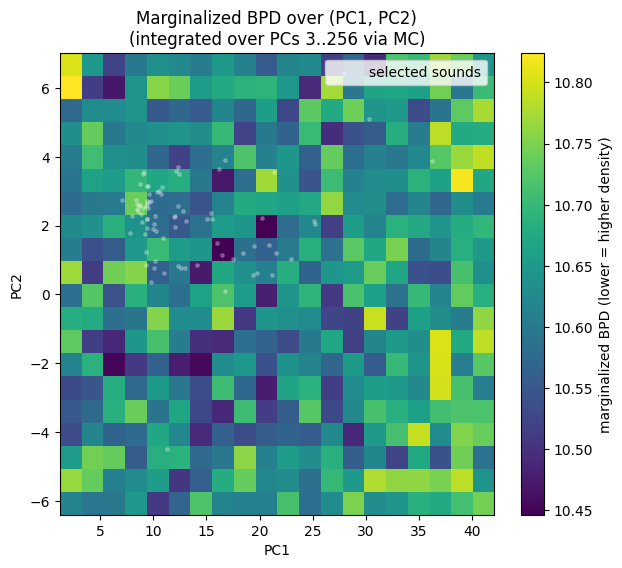

Grid points: 400, MC per point: 32, total evals: 12800


In [32]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------------------------
# settings
# ---------------------------
assert x_numpy.ndim == 2 and x_numpy.shape[1] == 256
nx, ny = 20, 20          # grid on (PC1, PC2)
M = 32                   # MC samples for dims 3..256 per grid point
batch_eval = 1024        # eval chunk size for compute_likelihood
rng = np.random.default_rng(0)

# ---------------------------
# 1) build broad (PC1, PC2) grid
# ---------------------------
z = x_numpy[:, :2]
z_min, z_max = z.min(axis=0), z.max(axis=0)
pad_frac = 0.20
span = z_max - z_min
lo = z_min - pad_frac * span
hi = z_max + pad_frac * span

g1 = np.linspace(lo[0], hi[0], nx)
g2 = np.linspace(lo[1], hi[1], ny)
G1, G2 = np.meshgrid(g1, g2)  # [ny, nx]
grid2 = np.stack([G1.ravel(), G2.ravel()], axis=1)  # [P,2]
P = grid2.shape[0]

# empirical pool for dims 3..256
tail_pool = x_numpy[:, 2:]  # [N,254]

# ---------------------------
# 2) construct MC-augmented 256D points
#    shape: [P*M, 256]
# ---------------------------
# sample M tail vectors per grid point
tail_idx = rng.integers(0, tail_pool.shape[0], size=P * M)
tail_samples = tail_pool[tail_idx]  # [P*M,254]

# repeat each grid point M times
head_repeat = np.repeat(grid2, M, axis=0)  # [P*M,2]

grid_full = np.empty((P * M, 256), dtype=np.float32)
grid_full[:, :2] = head_repeat
grid_full[:, 2:] = tail_samples.astype(np.float32)

x_grid = torch.tensor(grid_full, dtype=torch.float32, device=device).view(-1, 1, 1, 256)

# ---------------------------
# 3) evaluate likelihood in chunks
# ---------------------------
vals = []
with torch.no_grad():
    for s in range(0, x_grid.shape[0], batch_eval):
        e = min(s + batch_eval, x_grid.shape[0])
        out = compute_likelihood(score_model, input_stats=x_grid[s:e], ckpt=ckpt_path)
        if torch.is_tensor(out):
            out = out.detach().cpu().numpy()
        out = np.ravel(np.asarray(out))
        vals.append(out)

bpd_all = np.concatenate(vals, axis=0)  # [P*M]
assert bpd_all.size == P * M

# ---------------------------
# 4) marginalize over dims 3..256 using log-mean-exp
#    assumes lower bpd = higher likelihood
# ---------------------------
bpd_pm = bpd_all.reshape(P, M)         # [P,M]
logp_pm = -bpd_pm                      # proportional to log-likelihood

# stable logmeanexp over M
a = np.max(logp_pm, axis=1, keepdims=True)
logmeanexp = a[:, 0] + np.log(np.mean(np.exp(logp_pm - a), axis=1))
bpd_marginal = -logmeanexp             # [P]

bpd_grid = bpd_marginal.reshape(ny, nx)

# ---------------------------
# 5) visualize marginalized surface
# ---------------------------
plt.figure(figsize=(7, 6))
im = plt.imshow(
    bpd_grid,
    origin="lower",
    extent=[g1.min(), g1.max(), g2.min(), g2.max()],
    aspect="auto",
    cmap="viridis",
)
plt.scatter(x_numpy[:, 0], x_numpy[:, 1], s=6, c="white", alpha=0.25, label="selected sounds")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Marginalized BPD over (PC1, PC2)\n(integrated over PCs 3..256 via MC)")
plt.colorbar(im, label="marginalized BPD (lower = higher density)")
plt.legend(loc="best")
plt.show()

print(f"Grid points: {P}, MC per point: {M}, total evals: {P*M}")
